In [53]:
from dataclasses import dataclass, replace
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [54]:
@dataclass(frozen=True)
class Params:
    """Field order follows Table 2's row order."""
    kappa: float; sigma_chi: float; lambda_chi: float
    mu_xi: float;  sigma_xi: float;  mu_xi_star: float; rho: float

    @property
    def lambda_xi(self):  return self.mu_xi - self.mu_xi_star
    @property
    def premia(self):     return (self.lambda_chi, self.lambda_xi)
    @property
    def half_life(self):  return np.log(2)/self.kappa

In [55]:
ENRON   = Params(1.19, 0.158, 0.014,  -0.0386, 0.115, 0.0161, 0.189)
FUTURES = Params(1.49, 0.286, 0.157,  -0.0125, 0.145, 0.0115, 0.300)

# Footnote 9: Figures 1 and 2 use mu_xi = 3%, not the MLE. Figure 2 also sets
# lambda_chi = 5% with (chi0, xi0) shifted by -/+ Delta/kappa to hold S_0 fixed.
ENRON_FIG1 = replace(ENRON, mu_xi=0.03)
_D         = 0.05 - ENRON.lambda_chi
ENRON_FIG2 = replace(ENRON_FIG1, lambda_chi=0.05)

CHI0, XI0       = 0.119, 2.857                  # May 16, 1996
CHI0_F2, XI0_F2 = CHI0 - _D/ENRON.kappa, XI0 + _D/ENRON.kappa

In [56]:
def cov(t, p):
    """Cov[(chi_t, xi_t)] -- Eq (3b). Identical under both measures, Eq (8b)."""
    v_chi = (1 - np.exp(-2*p.kappa*t)) * p.sigma_chi**2 / (2*p.kappa)
    v_xi  = p.sigma_xi**2 * t
    c     = (1 - np.exp(-p.kappa*t)) * p.rho * p.sigma_chi * p.sigma_xi / p.kappa
    return np.array([[v_chi, c], [c, v_xi]])

In [57]:
def drift(p, lam_chi=0.0, lam_xi=0.0):
    """(level chi reverts to, drift rate of xi).

    lam = 0        -> Eq (1), (2):    reverts to 0,               drifts at mu_xi
    lam = p.premia -> Eq (7a), (7b):  reverts to -lam_chi/kappa,  drifts at mu_xi*

    There is one process. The premia select which drift it runs at.
    """
    return -lam_chi/p.kappa, p.mu_xi - lam_xi


def simulate(chi0, xi0, p, dt, n_steps, lam_chi=0.0, lam_xi=0.0, seed=None):
    """Exact discretisation:
         chi_i = e^{-k dt} chi_{i-1} + (1 - e^{-k dt}) theta + eps_chi
         xi_i  = xi_{i-1} + m dt + eps_xi
       with (eps_chi, eps_xi) ~ N(0, cov(dt)).
    """
    rng   = np.random.default_rng(seed)
    theta, m = drift(p, lam_chi, lam_xi)
    decay = np.exp(-p.kappa*dt)
    L     = np.linalg.cholesky(cov(dt, p))

    chi, xi = np.empty(n_steps+1), np.empty(n_steps+1)
    chi[0], xi[0] = chi0, xi0
    for i in range(1, n_steps+1):
        eps = L @ rng.standard_normal(2)
        chi[i] = decay*chi[i-1] + (1 - decay)*theta + eps[0]
        xi[i]  = xi[i-1] + m*dt + eps[1]
    return chi, xi

In [58]:
def E_state(t, p, chi0=CHI0, xi0=XI0, lam_chi=0.0, lam_xi=0.0):
    """E[(chi_t, xi_t)] -- Eq (3a); with premia, the Eq (8a) state vector."""
    t = np.asarray(t, float)
    theta, m = drift(p, lam_chi, lam_xi)
    decay = np.exp(-p.kappa*t)
    return decay*chi0 + (1 - decay)*theta, xi0 + m*t


def E_log_spot(t, p, chi0=CHI0, xi0=XI0, lam_chi=0.0, lam_xi=0.0):
    """E[ln S_t] -- Eq (4a); with premia, Eq (8a)."""
    a, b = E_state(t, p, chi0, xi0, lam_chi, lam_xi)
    return a + b


def var_log_spot(t, p):
    """Var[ln S_t] -- Eq (4b) = Eq (8b). Vectorised in t; no premia enter."""
    t = np.asarray(t, float)
    return ((1 - np.exp(-2*p.kappa*t)) * p.sigma_chi**2 / (2*p.kappa)
            + p.sigma_xi**2 * t
            + 2*(1 - np.exp(-p.kappa*t)) * p.rho * p.sigma_chi * p.sigma_xi / p.kappa)


def log_E_spot(t, p, chi0=CHI0, xi0=XI0, lam_chi=0.0, lam_xi=0.0):
    """ln E[S_t] = E[ln S_t] + Var[ln S_t]/2 -- Eq (5); with premia, Eq (9)."""
    return E_log_spot(t, p, chi0, xi0, lam_chi, lam_xi) + 0.5*var_log_spot(t, p)


def expected_spot(t, p, chi0=CHI0, xi0=XI0):
    """E[S_t] -- Eq (5). No premia."""
    return np.exp(log_E_spot(t, p, chi0, xi0))


def futures_price(T, p, chi0=CHI0, xi0=XI0):
    """F_{T,0} = E*[S_T] -- Eq (9). Premia switched on."""
    return np.exp(log_E_spot(T, p, chi0, xi0, *p.premia))


def risk_premium(t, p):
    """ln E[S_t] - ln F_{t,0} = (1-e^{-kt}) lam_chi/kappa + lam_xi t."""
    t = np.asarray(t, float)
    return (1 - np.exp(-p.kappa*t))*p.lambda_chi/p.kappa + p.lambda_xi*t

In [59]:
def A(T, p):
    """A(T) of Eq (9), written out."""
    T = np.asarray(T, float)
    k = p.kappa
    drift_part = p.mu_xi_star*T - (1 - np.exp(-k*T))*p.lambda_chi/k
    convexity  = 0.5*((1 - np.exp(-2*k*T))*p.sigma_chi**2/(2*k)
                      + p.sigma_xi**2*T
                      + 2*(1 - np.exp(-k*T))*p.rho*p.sigma_chi*p.sigma_xi/k)
    return drift_part + convexity


def log_futures(T, p, chi0=CHI0, xi0=XI0):
    """ln F_{T,0} = e^{-kT} chi_0 + xi_0 + A(T) -- the affine form of Eq (9)."""
    T = np.asarray(T, float)
    return np.exp(-p.kappa*T)*chi0 + xi0 + A(T, p)


def asymptote(p, xi0=XI0, lam_chi=0.0, lam_xi=0.0):
    """(intercept, slope) of the long-run straight line -- Eq (6), or its
    T -> inf counterpart for the futures curve when premia are supplied."""
    theta, m = drift(p, lam_chi, lam_xi)
    return (xi0 + theta + p.sigma_chi**2/(4*p.kappa)
            + p.rho*p.sigma_chi*p.sigma_xi/p.kappa,
            m + 0.5*p.sigma_xi**2)

In [60]:
p, Ts = ENRON_FIG1, np.linspace(0, 10, 201)

assert np.isclose(cov(0.7, p).sum(), var_log_spot(0.7, p))
assert np.isclose(A(0.0, p), 0.0, atol=1e-14)
assert np.allclose(log_futures(Ts, p), log_E_spot(Ts, p, CHI0, XI0, *p.premia))
for prm in (ENRON, FUTURES, ENRON_FIG1, ENRON_FIG2):
    assert np.allclose(A(Ts, prm),
                       log_E_spot(Ts, prm, 0.0, 0.0, *prm.premia), atol=1e-12)
print("A(T): closed form == moment route, all four parameter sets   OK")

for t in (0.25, 1.0, 5.0):
    gap = E_log_spot(t, p) - E_log_spot(t, p, CHI0, XI0, *p.premia)
    assert np.isclose(gap, risk_premium(t, p))
print("risk-premium identity   OK")
print(f"  premium at t=1: {risk_premium(1.0, p):.6f}   "
      f"t=5: {risk_premium(5.0, p):.6f}   t=9: {risk_premium(9.0, p):.6f}")

assert np.isclose(futures_price(0.0, p), expected_spot(0.0, p))
print(f"F_0 = E[S_0] = {futures_price(0.0, p):.4f}   (paper: 19.61)")

b_p, m_p = asymptote(ENRON_FIG2, XI0_F2)
b_q, m_q = asymptote(ENRON_FIG2, XI0_F2, *ENRON_FIG2.premia)
assert np.isclose(b_p - b_q, ENRON_FIG2.lambda_chi/ENRON_FIG2.kappa)
assert np.isclose(m_p - m_q, ENRON_FIG2.lambda_xi)
print(f"asymptote gap = lam_chi/kappa = {b_p-b_q:.5f}, "
      f"slope gap = lam_xi = {m_p-m_q:.6f}   OK")

# lambda_chi indeterminacy (Sec. 6.1): Q-law invariant, P-law is not
assert np.allclose(log_E_spot(Ts, p, CHI0, XI0, *p.premia),
                   log_E_spot(Ts, ENRON_FIG2, CHI0_F2, XI0_F2, *ENRON_FIG2.premia))
print("lambda_chi indeterminacy   OK")

A(T): closed form == moment route, all four parameter sets   OK
risk-premium identity   OK
  premium at t=1: 0.022086   t=5: 0.081234   t=9: 0.136864
F_0 = E[S_0] = 19.6092   (paper: 19.61)
asymptote gap = lam_chi/kappa = 0.04202, slope gap = lam_xi = 0.013900   OK
lambda_chi indeterminacy   OK


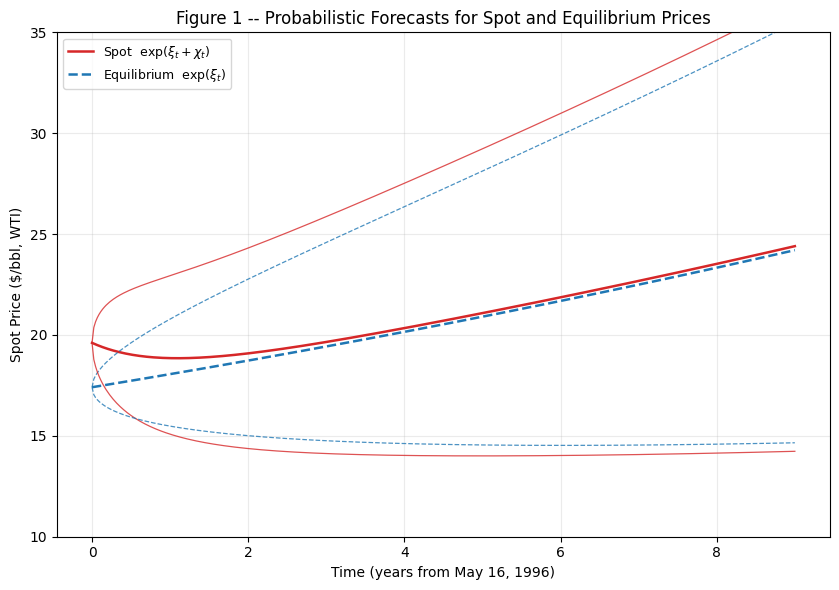

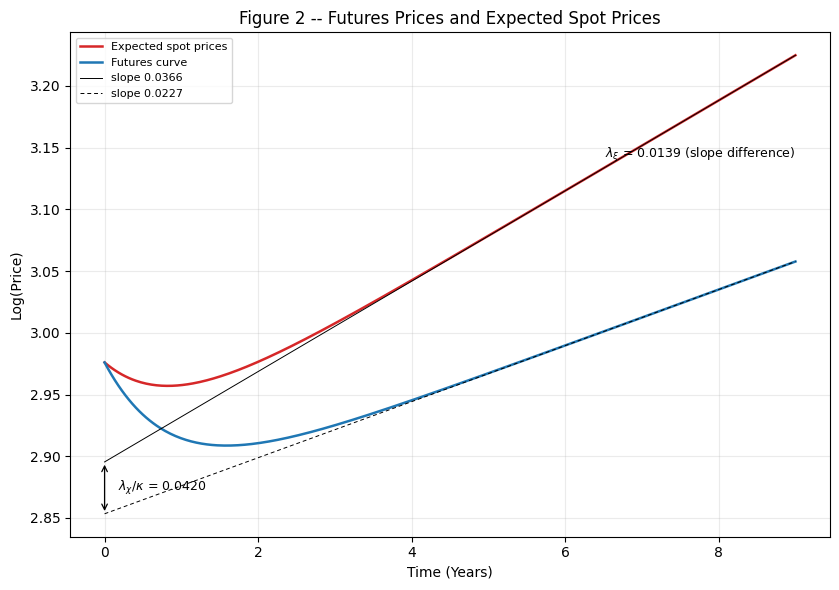

In [61]:
def figure_1(p=ENRON_FIG1, chi0=CHI0, xi0=XI0):
    t = np.linspace(0, 9, 400)
    sd_s, sd_e = np.sqrt(var_log_spot(t, p)), p.sigma_xi*np.sqrt(t)
    m_s, m_e   = E_log_spot(t, p, chi0, xi0), xi0 + p.mu_xi*t

    fig, ax = plt.subplots(figsize=(8.5, 6))
    ax.plot(t, expected_spot(t, p, chi0, xi0), 'C3', lw=1.8,
            label=r'Spot  $\exp(\xi_t+\chi_t)$')
    ax.plot(t, np.exp(m_e + 0.5*p.sigma_xi**2*t), 'C0--', lw=1.8,
            label=r'Equilibrium  $\exp(\xi_t)$')
    for q in (0.9, 0.1):
        ax.plot(t, np.exp(m_s + norm.ppf(q)*sd_s), 'C3', lw=0.9, alpha=0.8)
        ax.plot(t, np.exp(m_e + norm.ppf(q)*sd_e), 'C0--', lw=0.9, alpha=0.8)
    ax.set_xlabel('Time (years from May 16, 1996)')
    ax.set_ylabel('Spot Price ($/bbl, WTI)')
    ax.set_title('Figure 1 -- Probabilistic Forecasts for Spot and Equilibrium Prices')
    ax.set_ylim(10, 35); ax.grid(alpha=0.25); ax.legend(fontsize=9)
    fig.tight_layout(); plt.show()


def figure_2(p=ENRON_FIG2, chi0=CHI0_F2, xi0=XI0_F2):
    t = np.linspace(0, 9, 400)
    b_p, m_p = asymptote(p, xi0)
    b_q, m_q = asymptote(p, xi0, *p.premia)

    fig, ax = plt.subplots(figsize=(8.5, 6))
    ax.plot(t, log_E_spot(t, p, chi0, xi0), 'C3', lw=1.8, label='Expected spot prices')
    ax.plot(t, log_futures(t, p, chi0, xi0), 'C0', lw=1.8, label='Futures curve')
    ax.plot(t, b_p + m_p*t, 'k',  lw=0.7, label=f'slope {m_p:.4f}')
    ax.plot(t, b_q + m_q*t, 'k',  lw=0.7, ls=(0, (4, 3)), label=f'slope {m_q:.4f}')
    ax.annotate('', xy=(0, b_p), xytext=(0, b_q), arrowprops=dict(arrowstyle='<->', lw=0.9))
    ax.annotate(rf'$\lambda_\chi/\kappa$ = {p.lambda_chi/p.kappa:.4f}',
                (0, 0.5*(b_p+b_q)), textcoords='offset points', xytext=(10, -2), fontsize=9)
    ax.annotate(rf'$\lambda_\xi$ = {p.lambda_xi:.4f} (slope difference)',
                (9, 0.5*(b_p+m_p*9 + b_q+m_q*9)), ha='right', fontsize=9)
    ax.set_xlabel('Time (Years)'); ax.set_ylabel('Log(Price)')
    ax.set_title('Figure 2 -- Futures Prices and Expected Spot Prices')
    ax.grid(alpha=0.25); ax.legend(fontsize=8, loc='upper left')
    fig.tight_layout(); plt.show()

figure_1()
figure_2()

In [62]:
def mu_phi(t, T, p, chi0=CHI0, xi0=XI0):
    """E*[ln F_{T,t}] -- Sec. 3.2.

    NOTE: the paper's printed form omits the -(1-e^{-kt}) lambda_chi/kappa term
    in E*[chi_t] (cf. Eq 8a). Restored here; without it the martingale property
    E*[F_{T,t}] = F_{T,0} fails by (1-e^{-kt}) lambda_chi/kappa.
    """
    t, T = np.asarray(t, float), np.asarray(T, float)
    k = p.kappa
    E_chi_t = np.exp(-k*t)*chi0 - (1 - np.exp(-k*t))*p.lambda_chi/k
    return np.exp(-k*(T - t))*E_chi_t + xi0 + p.mu_xi_star*t + A(T - t, p)


def var_phi(t, T, p):
    """Var*[ln F_{T,t}] -- Sec. 3.2. Reduces to var_log_spot(T, p) at t = T."""
    t, T = np.asarray(t, float), np.asarray(T, float)
    k = p.kappa
    return (np.exp(-2*k*(T - t))*(1 - np.exp(-2*k*t))*p.sigma_chi**2/(2*k)
            + p.sigma_xi**2*t
            + 2*np.exp(-k*(T - t))*(1 - np.exp(-k*t))
              * p.rho*p.sigma_chi*p.sigma_xi/k)


def E_futures(t, T, p, chi0=CHI0, xi0=XI0):
    """E*[F_{T,t}] = exp(mu_phi + var_phi/2). Must equal F_{T,0} for all t."""
    return np.exp(mu_phi(t, T, p, chi0, xi0) + 0.5*var_phi(t, T, p))


def inst_vol_futures(T, p):
    """Instantaneous volatility of ln F_{T,0} -- Sec. 3.1. State-independent."""
    T = np.asarray(T, float)
    return np.sqrt(np.exp(-2*p.kappa*T)*p.sigma_chi**2 + p.sigma_xi**2
                   + 2*np.exp(-p.kappa*T)*p.rho*p.sigma_chi*p.sigma_xi)


def option_vol(T, p):
    """Annualised option volatility sigma_phi(T,T)/sqrt(T) -- Sec. 3.2,
    for an option expiring at the maturity of the futures contract."""
    T = np.asarray(T, float)
    return np.sqrt(var_phi(T, T, p)/T)

In [63]:
p = ENRON_FIG1

for T in (0.5, 5.0, 9.0):
    tt = np.linspace(0, T, 41)
    dev = np.abs(np.log(E_futures(tt, T, p)) - log_futures(T, p)).max()
    print(f"T = {T:>4}   max |ln E*[F_(T,t)] - ln F_(T,0)| = {dev:.2e}")
    assert dev < 1e-12

T = 5.0
assert np.isclose(var_phi(0.0, T, p), 0.0)
assert np.isclose(var_phi(T, T, p), var_log_spot(T, p))
assert np.isclose(mu_phi(0.0, T, p), log_futures(T, p))
assert np.isclose(mu_phi(T, T, p),
                  E_log_spot(T, p, CHI0, XI0, *p.premia))
print("boundary conditions at t=0 and t=T   OK")

h = 1e-6
print(f"d var_phi/dt at t=0: {(var_phi(h,T,p)-var_phi(0,T,p))/h:.10f}"
      f"   target {inst_vol_futures(T,p)**2:.10f}")

print(f"\ninst vol: T=0 {inst_vol_futures(0.0,p):.4f} "
      f"(= spot vol)   T=10 {inst_vol_futures(10.0,p):.4f} "
      f"(-> sigma_xi = {p.sigma_xi:.4f})")

T =  0.5   max |ln E*[F_(T,t)] - ln F_(T,0)| = 4.44e-16
T =  5.0   max |ln E*[F_(T,t)] - ln F_(T,0)| = 8.88e-16
T =  9.0   max |ln E*[F_(T,t)] - ln F_(T,0)| = 8.88e-16
boundary conditions at t=0 and t=T   OK
d var_phi/dt at t=0: 0.0132430671   target 0.0132430671

inst vol: T=0 0.2123 (= spot vol)   T=10 0.1150 (-> sigma_xi = 0.1150)


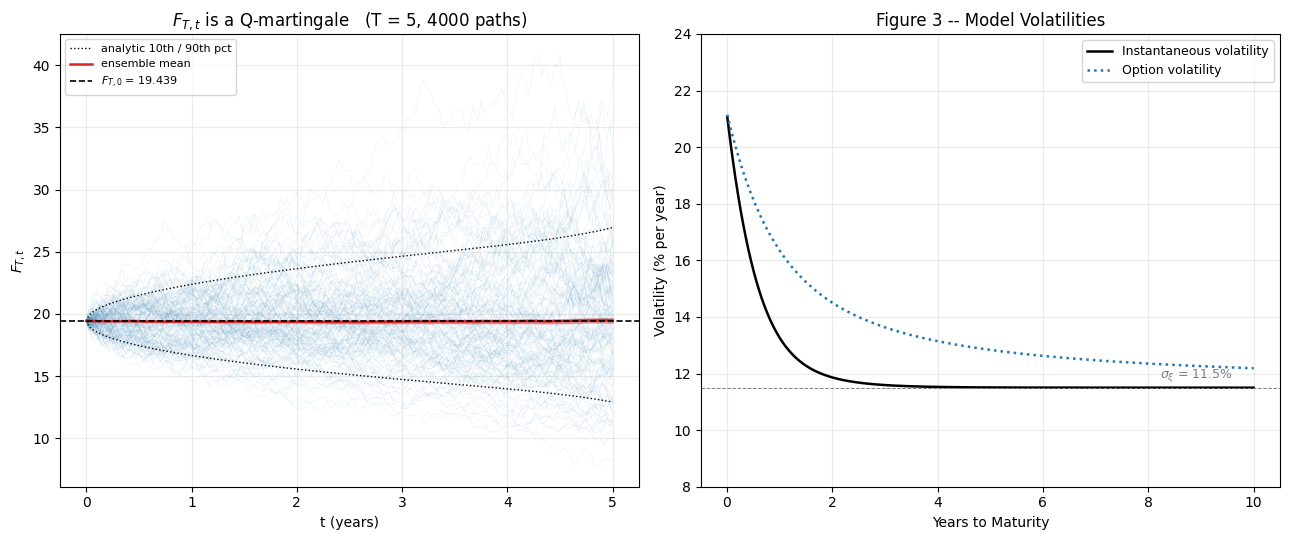

F_(T,0) = 19.4386   ensemble mean at t=T = 19.4774 +/- 0.0897   (z = +0.43)
analytic sd of ln F_(T,T) = 0.2870


In [64]:
def simulate_futures_paths(T, p, n_paths=4000, n_steps=200,
                           chi0=CHI0, xi0=XI0, seed=1):
    """Paths of F_{T,t} under Q on t in [0, T], via the affine form of Eq (9)."""
    rng = np.random.default_rng(seed)
    dt = T/n_steps
    t = np.arange(n_steps + 1)*dt
    theta, m = -p.lambda_chi/p.kappa, p.mu_xi_star
    decay = np.exp(-p.kappa*dt)
    L = np.linalg.cholesky(cov(dt, p))

    chi = np.full(n_paths, float(chi0))
    xi  = np.full(n_paths, float(xi0))
    F = np.empty((n_paths, n_steps + 1))
    F[:, 0] = np.exp(np.exp(-p.kappa*T)*chi + xi + A(T, p))
    for i in range(1, n_steps + 1):
        eps = rng.standard_normal((n_paths, 2)) @ L.T
        chi = decay*chi + (1 - decay)*theta + eps[:, 0]
        xi  = xi + m*dt + eps[:, 1]
        F[:, i] = np.exp(np.exp(-p.kappa*(T - t[i]))*chi + xi + A(T - t[i], p))
    return t, F


p, T = ENRON_FIG1, 5.0
t, F = simulate_futures_paths(T, p)
F0   = futures_price(T, p)
mean = F.mean(axis=0)
se   = F.std(axis=0, ddof=1)/np.sqrt(F.shape[0])
sd_a = np.sqrt(var_phi(t, T, p))

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

a = ax[0]
a.plot(t, F[:150].T, color='C0', lw=0.4, alpha=0.10)
a.plot(t, np.exp(mu_phi(t, T, p) + 1.2816*sd_a), 'k:', lw=1.0)
a.plot(t, np.exp(mu_phi(t, T, p) - 1.2816*sd_a), 'k:', lw=1.0,
       label='analytic 10th / 90th pct')
a.fill_between(t, mean - 2*se, mean + 2*se, color='C3', alpha=0.35)
a.plot(t, mean, 'C3', lw=1.8, label='ensemble mean')
a.axhline(F0, color='k', lw=1.2, ls='--', label=rf'$F_{{T,0}}$ = {F0:.3f}')
a.set_xlabel('t (years)'); a.set_ylabel(r'$F_{T,t}$')
a.set_title(rf'$F_{{T,t}}$ is a Q-martingale   (T = {T:.0f}, {F.shape[0]} paths)')
a.grid(alpha=0.25); a.legend(fontsize=8, loc='upper left')

a = ax[1]
TT = np.linspace(0.01, 10, 400)
inst = np.sqrt(np.exp(-2*p.kappa*TT)*p.sigma_chi**2 + p.sigma_xi**2
               + 2*np.exp(-p.kappa*TT)*p.rho*p.sigma_chi*p.sigma_xi)
opt  = np.sqrt(var_phi(TT, TT, p)/TT)
a.plot(TT, 100*inst, 'k',   lw=1.8, label='Instantaneous volatility')
a.plot(TT, 100*opt,  'C0:', lw=1.8, label='Option volatility')
a.axhline(100*p.sigma_xi, color='grey', lw=0.7, ls='--')
a.annotate(rf'$\sigma_\xi$ = {100*p.sigma_xi:.1f}%', (9.6, 100*p.sigma_xi + 0.35),
           ha='right', fontsize=9, color='grey')
a.set_xlabel('Years to Maturity'); a.set_ylabel('Volatility (% per year)')
a.set_title('Figure 3 -- Model Volatilities')
a.set_ylim(8, 24); a.grid(alpha=0.25); a.legend(fontsize=9)

fig.tight_layout(); plt.show()

print(f"F_(T,0) = {F0:.4f}   ensemble mean at t=T = {mean[-1]:.4f} "
      f"+/- {se[-1]:.4f}   (z = {(mean[-1]-F0)/se[-1]:+.2f})")
print(f"analytic sd of ln F_(T,T) = {sd_a[-1]:.4f}")

In [65]:
for T_ in (1.0, 3.0, 5.0, 9.0):
    tt = np.linspace(0, T_, 300)
    dev = np.abs(np.log(E_futures(tt, T_, p)) - log_futures(T_, p)).max()
    assert dev < 1e-12, (T_, dev)
print("martingale identity exact to machine precision   OK")

martingale identity exact to machine precision   OK
